# K-Nearest-Neighbors (KNN), Decision Trees, and Random Forest

## KNN Classification

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# We will use an example dataset that comes with scikit learn
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

In [2]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [3]:
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
X = iris.data[['sepal length (cm)', 'sepal width (cm)']]
y = iris.target

In [6]:
X

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


In [7]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [8]:
y.unique()

array([0, 1, 2])

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

In [10]:
#Scaling the data w.r.t train set mean and variance

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [11]:
#KNN classifier is fitted to your data with uniform weights (each data point is equally weighted) p=2 means euclidean distance
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2)

#Try the different arguments following the link below
#https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
y_test_preds = knn.predict(X_test)
print(y_test_preds)

[1 0 2 0 2 0 0 0 1 1 0 0 1 0 0 2 1 2 0 0 0 0 1 0 1 1 1 2 1 2]


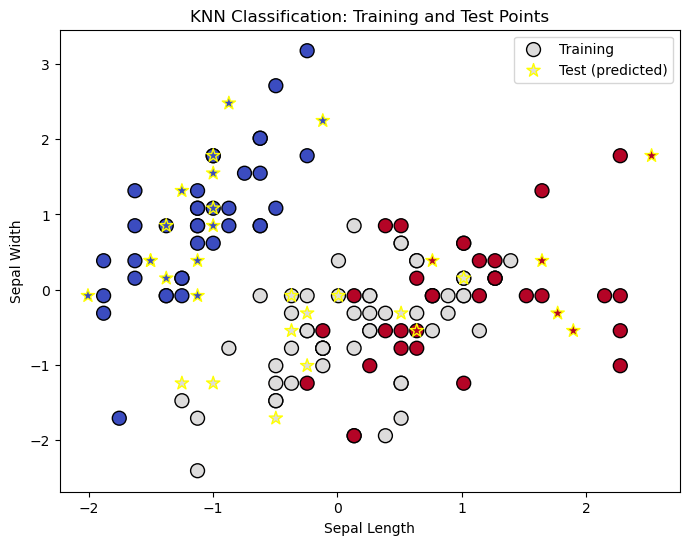

In [13]:
plt.figure(figsize=(8,6))

# Training points
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=100, label='Training')


# Test points with predicted class
plt.scatter(X_test[:,0], X_test[:,1], c=y_test_preds, cmap='coolwarm', edgecolor='yellow', s=100, marker='*', label='Test (predicted)')


plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('KNN Classification: Training and Test Points')
plt.legend()
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test,y_test_preds)
print(cm)

accuracy = accuracy_score(y_test, y_test_preds)*100
print('Accuracy of the model is ' + str(round(accuracy, 2)) + ' %.')

[[14  0  0]
 [ 0  5  0]
 [ 0  5  6]]
Accuracy of the model is 83.33 %.


In [15]:
from sklearn.model_selection import cross_val_score

# creating list of K for KNN
k_list = list(range(1,50))

# creating list of cv scores
cv_scores = []

# perform 10-fold cross validation
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

<Figure size 640x480 with 0 Axes>

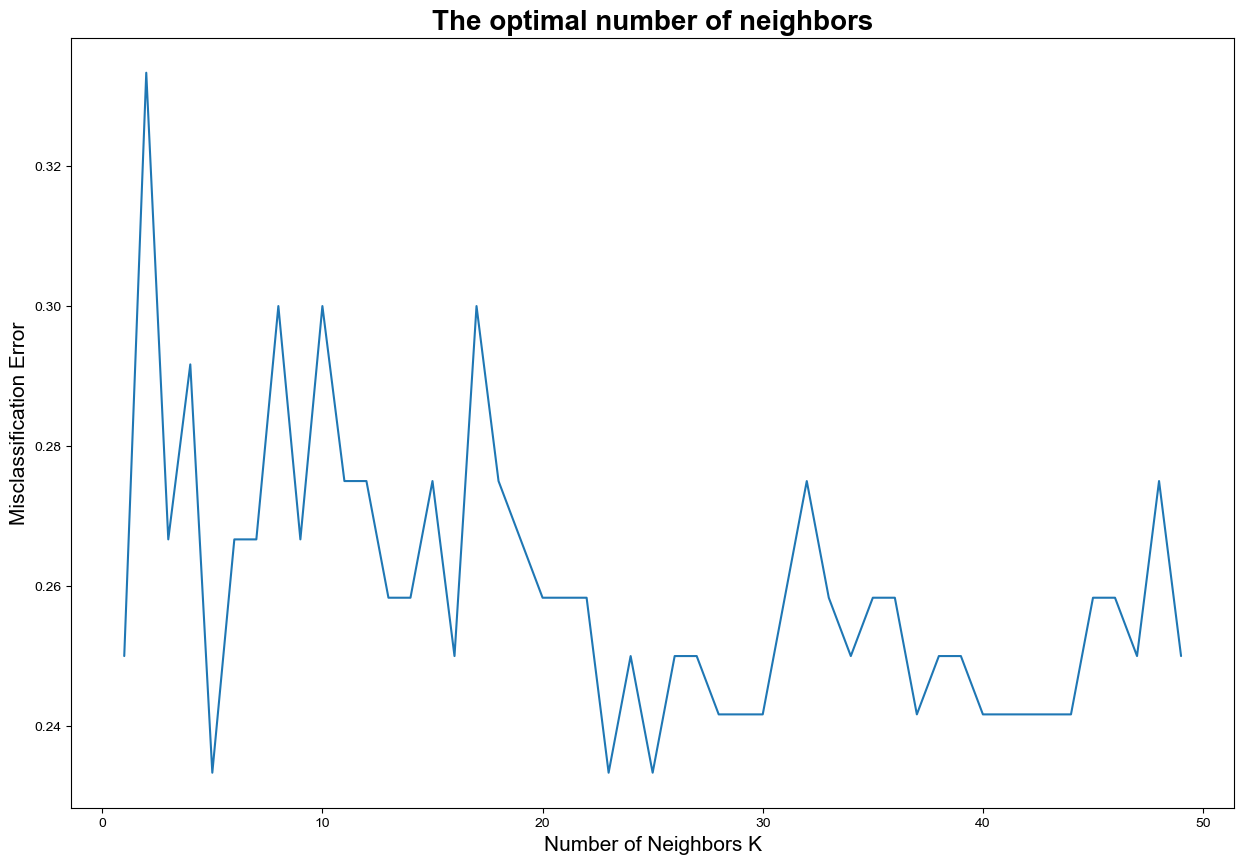

In [16]:
#To find the optimal number of neighbors as the hyper-parameter you can look for the one with minimum classification error
import seaborn as sns

# changing to misclassification error
ME = [1-x for x in cv_scores]

plt.figure()
plt.figure(figsize=(15,10))
plt.title('The optimal number of neighbors', fontsize=20, fontweight='bold')
plt.xlabel('Number of Neighbors K', fontsize=15)
plt.ylabel('Misclassification Error', fontsize=15)
sns.set_style("whitegrid")

plt.plot(k_list, ME)

plt.show()

## Decision Tree Classifier

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=100)

#Try the different arguments following the link below
#https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=100)

In [18]:
dt.feature_importances_

array([0.68431201, 0.31568799])

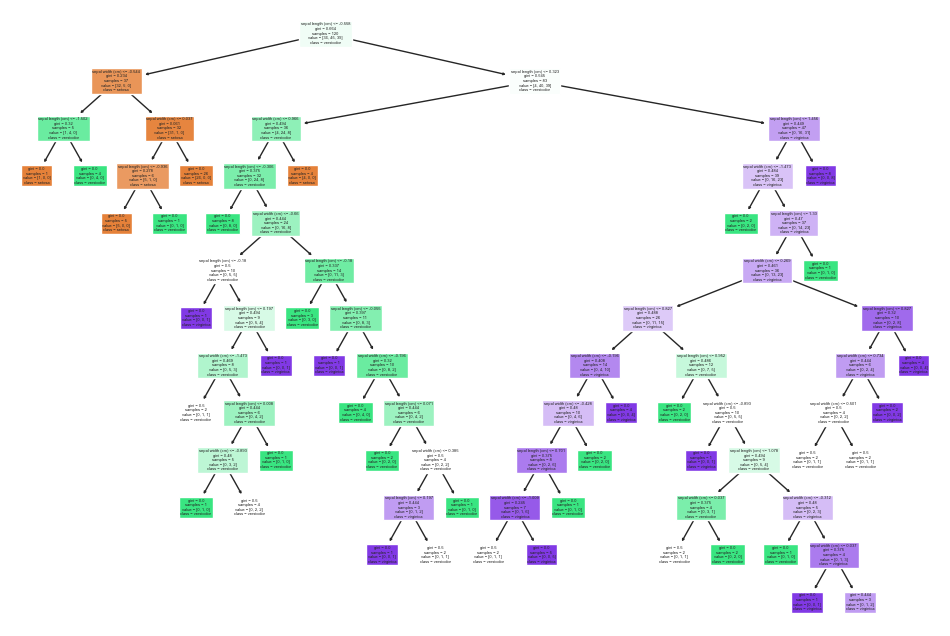

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(dt, 
          feature_names=list(X.columns), 
          class_names=['setosa','versicolor','virginica'],
          filled=True)
plt.show()


# Random Forest Classifier

In [20]:
#Random forest is trained with 50 trees with max_features='sqrt' means that the square root of total number of features will be considered for the split. 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, random_state=17, max_features='sqrt')

#Try the different arguments following the link below
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=17)

In [21]:
rf.feature_importances_

array([0.62255307, 0.37744693])

In [22]:
#Now to see if the random forest is able to reduce the variance and improve the performance?

from sklearn.model_selection import cross_val_score


dt = DecisionTreeClassifier(random_state = 0)
scores = cross_val_score(dt, X_train, y_train, cv=10, scoring='accuracy')
print('Mean accuracy for decision tree', scores.mean())
print('Standard deviation across the folds', scores.std())
#mean and standard deviation of accuracy for decision tree across the 10 folds 

rf = RandomForestClassifier(n_estimators=100, random_state=17, max_features='sqrt')
scores = cross_val_score(rf, X_train, y_train, cv=10, scoring='accuracy')
print('Mean accuracy for random forest', scores.mean())
print('Standard deviation across the folds', scores.std())
#mean and standard deviation of accuracy for random forest across the 10 folds


Mean accuracy for decision tree 0.7
Standard deviation across the folds 0.15898986690282427
Mean accuracy for random forest 0.7333333333333334
Standard deviation across the folds 0.1224744871391589
